# Notebook 2 Generating a Transient Population

In this notebook we generate a mixed population of supernovae (SN) and kilonovae (KN) 
within the synthetic universe constructed in Notebook 1.

We assume:

- Supernova rate ∝ Star Formation Rate (SFR)
- Kilonova rate ∝ Total Stellar Mass (M_star)
- Absolute magnitude M = -16 for both populations
- Survey duration T = 50,000 years

This notebook produces an intrinsic transient population and computes 
their apparent magnitudes using the distance modulus.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import UnivariateSpline


## Load Synthetic Galaxy Catalogue

We import the galaxy catalogue generated in Notebook 1.

This catalogue contains:

- Distance (Mpc)
- Stellar Mass (M_star)
- Star Formation Rate (SFR)
- Galaxy properties

In [2]:
galaxies = pd.read_csv("galaxy_catalog.csv")

print("Number of galaxies:", len(galaxies))
galaxies.head()


Number of galaxies: 50000


,x,y,z,distance,M_star,SFR,is_quiescent,L
0,-135.980529,-75.625049,-150.179101,216.248964,1.166272e+10,0.002688,True,0.009308
1,-290.744878,-49.749084,3.234814,294.988169,5.648145e+09,0.001249,True,0.001237
2,-127.169016,172.656237,164.673388,270.369118,5.612331e+09,0.007538,True,0.002440
3,-222.527760,9.495705,-119.665529,252.841079,5.976691e+09,0.001379,True,0.001037
4,-105.454176,119.467975,26.267419,161.502811,3.702149e+09,0.001622,True,0.001927


## Physical Event Rates

We assume simple host galaxy scaling relations.

The supernova rate in each galaxy is proportional to its star formation rate.

The kilonova rate in each galaxy is proportional to its stellar mass.

---

### Assumptions

- Core collapse supernovae trace ongoing star formation.
- Kilonovae trace stellar mass as a proxy for delayed mergers.
- Rates are constant over the survey duration.

Survey duration: 50,000 years.

---

### Normalizations

Supernova normalization: 1 × 10^-6 events per (M☉/yr) per year of star formation.

Kilonova normalization: 1 × 10^-18 events per year per solar mass of stellar mass.

These values reproduce realistic order-of-magnitude local event rates.

In [3]:
A_SN = 1e-6       # SN per (Msun/yr) per year
A_KN = 1e-18      # KN per Msun per year
T_survey = 50000.0     # years

## Sampling Event Counts

For each galaxy, we compute the expected number of events over the survey duration.

The expected supernova count scales with star formation rate.

The expected kilonova count scales with stellar mass.

Actual event numbers are drawn from a Poisson distribution with these expected values as the mean.

The expected totals represent the ensemble average.

The realised totals represent one Monte Carlo survey realisation.

In [4]:
lambda_SN = A_SN * galaxies["SFR"] * T_survey
lambda_KN = A_KN * galaxies["M_star"] * T_survey

N_SN = np.random.poisson(lambda_SN)
N_KN = np.random.poisson(lambda_KN)

print("Total expected SN:", lambda_SN.sum())
print("Total expected KN:", lambda_KN.sum())

print("Total realised SN:", N_SN.sum())
print("Total realised KN:", N_KN.sum())

Total expected SN: 504.6184724113488
Total expected KN: 13.983174577575706
Total realised SN: 480
Total realised KN: 8


## Construct Event Catalogue

We expand galaxy level event counts into an event-level table.

Each event stores:

- Event type (SN or KN)
- Host galaxy distance

This produces the intrinsic transient population.

In [5]:
events = []

for i in range(len(galaxies)):
    d = galaxies["distance"].iloc[i]

    for _ in range(N_SN[i]):
        events.append({"type": "SN", "distance": d})

    for _ in range(N_KN[i]):
        events.append({"type": "KN", "distance": d})

events = pd.DataFrame(events)

print("Total SN:", (events["type"] == "SN").sum())
print("Total KN:", (events["type"] == "KN").sum())
print("Total events:", len(events))


Total SN: 480
Total KN: 8
Total events: 488


## Convert to Apparent Magnitude

We assume a fixed absolute magnitude:

M = -16

The distance modulus is:

μ = 5 log10(d_Mpc) + 25

The apparent magnitude is:

m = M + μ



In [6]:
M_abs = -16

events["mu"] = 5 * np.log10(events["distance"]*1e6) - 5
events["m"] = M_abs + events["mu"]

events.head()

,type,distance,mu,m
0,SN,199.583467,36.500623,20.500623
1,SN,293.474569,37.337852,21.337852
2,SN,136.619005,35.677556,19.677556
3,SN,294.956845,37.348792,21.348792
4,SN,282.873784,37.257964,21.257964


### Brightness Range of Injected Events

This cell computes the apparent magnitude range of the simulated transient population.

- The minimum value of `m` corresponds to the brightest detected event.
- The maximum value of `m` corresponds to the faintest detected event.

This provides a quick validation that the injected supernovae and kilonovae span a physically reasonable magnitude range within the survey limits.


In [7]:
print("Brightest event:", events["m"].min())
print("Faintest event:", events["m"].max())

Brightest event: 16.573214203022467
Faintest event: 21.38410938620411


### Apparent Magnitude as a Function of Distance

This cell compares the simulated events to the theoretical distance–magnitude relation.

- A smooth distance grid `d` is created between the minimum and maximum event distances.


  where an absolute magnitude of M = -16 is assumed.
- The simulated event magnitudes are plotted as scatter points.
- The theoretical curve is overlaid for comparison.
- The y-axis is inverted because lower magnitudes correspond to brighter objects.

This verifies that the injected events follow the expected luminosity–distance scaling.


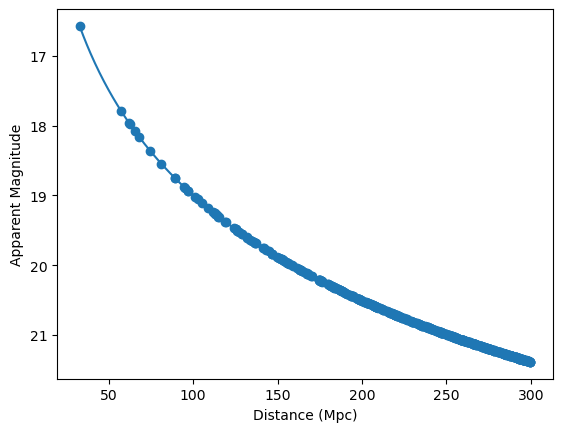

In [8]:

d = np.linspace(events["distance"].min(), 
                events["distance"].max(), 500)

m_model = -16 + 5*np.log10(d*1e6) - 5

plt.figure()
plt.scatter(events["distance"], events["m"])
plt.plot(d, m_model)

plt.xlabel("Distance (Mpc)")
plt.ylabel("Apparent Magnitude")
plt.gca().invert_yaxis()
plt.show()

### Apparent Magnitude Distribution: Supernovae vs Kilonovae

This cell compares the apparent magnitude distributions of Supernovae (SN) and Kilonovae (KN).

- The events are separated by type (`SN` and `KN`).
- Histograms of their apparent magnitudes (`m`) are plotted.
- A logarithmic y-axis is used to clearly show differences in event counts.
- This highlights the relative abundance of SN compared to the much rarer KN population.

The plot allows a direct visual comparison of brightness distributions and population imbalance between the two transient types.


[]

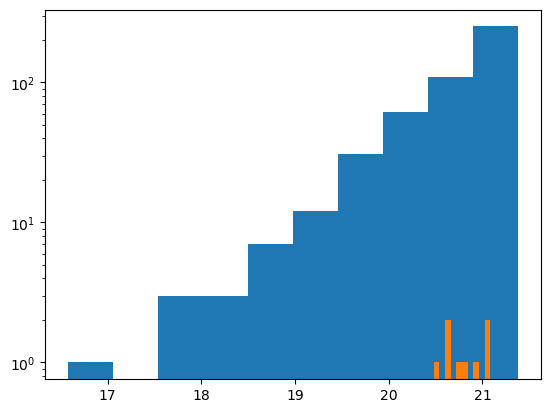

In [9]:
plt.hist(events[events['type']=='SN']['m'], label='SN')
plt.hist(events[events['type']=='KN']['m'], label='KN')

plt.semilogy()

### Inspecting Kilonova Events in the Synthetic Sample

This cell filters the event catalogue to show only Kilonova (KN) events.


In [10]:
events[events['type']=='KN']


,type,distance,mu,m
53,KN,240.493831,36.905520,20.905520
83,KN,260.971034,37.082962,21.082962
91,KN,255.274556,37.035038,21.035038
93,KN,230.402250,36.812434,20.812434
163,KN,221.593075,36.727781,20.727781
177,KN,210.399664,36.615225,20.615225
188,KN,197.747285,36.480553,20.480553
317,KN,211.591308,36.627489,20.627489


## SN 1993J r-band Light Curve

This cell loads the observed r-band light curve of SN 1993J (Type IIb supernova) from `sn1993j_rband.csv`. Columns: `t_days`, `mag`, `mag_err`, `band`, `upperlimit`. All 164 points are detections (no upper limits). This will serve as the supernova template.

In [ ]:
df_93 = pd.read_csv(os.path.expanduser("~/Downloads/sn1993j_rband.csv"))

plt.figure(figsize=(6, 4))
plt.scatter(df_93["t_days"], df_93["mag"], s=25)
plt.gca().invert_yaxis()
plt.xlabel("Days since explosion")
plt.ylabel("r-band magnitude")
plt.title("SN 1993J r-band Light Curve")
plt.tight_layout()
plt.show()

## Loading the AT2017gfo r-band Kilonova Data

This cell loads AT2017gfo (GW170817 kilonova) r-band photometry from `at2017gfo_rband.csv`. Columns: `t_days`, `mag`, `mag_err`, `band`, `upperlimit`. We split into detections and upper limits using the `upperlimit` column directly — no heuristic filtering needed.

In [ ]:
df_kn = pd.read_csv(os.path.expanduser("~/Downloads/at2017gfo_rband.csv"))

# New file has an explicit upperlimit column — use it directly
kn_det = df_kn[df_kn["upperlimit"] == False].copy()
kn_lim = df_kn[df_kn["upperlimit"] == True].copy()

print(f"AT2017gfo r-band: {len(kn_det)} detections, {len(kn_lim)} upper limits")
df_kn.head()

### AT2017gfo r-band Detections and Upper Limits

The new `at2017gfo_rband.csv` file contains an explicit `upperlimit` column. We split directly on that — no heuristic magnitude or phase cuts needed. Detections are used for spline fitting; upper limits are plotted for reference only.

### AT2017gfo r-band Light Curve

We plot detections (circles) and upper limits (downward triangles) for AT2017gfo in r-band. The kilonova fades rapidly — later upper limits mark epochs where it fell below the instrument detection threshold.

## Apparent r-band Light Curves

This cell plots the observed r-band light curves of SN 1993J and AT2017gfo.

- The x-axis shows time in days since explosion (SN 1993J) or merger (AT2017gfo).
- The y-axis shows apparent r-band magnitude.
- The y-axis is inverted because smaller magnitudes are brighter.
- Each point represents a real observational measurement.

This allows direct visual comparison between a Type IIb supernova and a kilonova in the same photometric band.

In [ ]:
plt.figure(figsize=(6, 4))
plt.scatter(kn_det["t_days"], kn_det["mag"], s=25, label="Detection")
plt.scatter(kn_lim["t_days"], kn_lim["mag"], marker="v", s=40, label="Upper limit")
plt.gca().invert_yaxis()
plt.xlabel("Days since merger")
plt.ylabel("r-band magnitude")
plt.title("AT2017gfo r-band light curve")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
phase_sn = df_93["t_days"]
r_sn     = df_93["mag"]

phase_kn_det = kn_det["t_days"]
r_kn_det     = kn_det["mag"]
phase_kn_lim = kn_lim["t_days"]
r_kn_lim     = kn_lim["mag"]

plt.figure(figsize=(8, 5))
plt.scatter(phase_sn,     r_sn,     s=30, label="SN 1993J (Type IIb)")
plt.scatter(phase_kn_det, r_kn_det, s=30, label="AT2017gfo (Detection)")
plt.scatter(phase_kn_lim, r_kn_lim, marker="v", s=40, label="AT2017gfo (Upper limit)")
plt.xlabel("Days since explosion / merger")
plt.ylabel("Apparent r-band magnitude")
plt.title("Apparent r-band Light Curves")
plt.gca().invert_yaxis()
plt.xlim(0, 45)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

## Absolute r-band Light Curves

This cell converts both light curves to absolute magnitude.

- The distance modulus is computed using:
  μ = 5 log10(d_Mpc × 10^6) − 5
- SN 1993J is assumed to be at 3.6 Mpc.
- AT2017gfo is assumed to be at 40 Mpc.
- Absolute magnitude is computed as:
  M = m − μ

This allows direct physical comparison of intrinsic brightness.

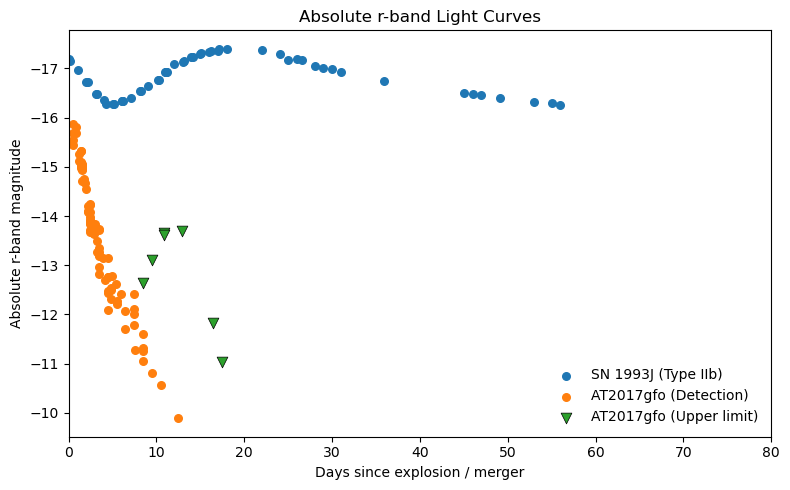

In [15]:
d_93 = 3.6    # Mpc
d_kn = 40.0   # Mpc

mu_93 = 5 * np.log10(d_93 * 1e6) - 5
mu_kn = 5 * np.log10(d_kn * 1e6) - 5

M_93      = r_sn - mu_93
M_kn_det  = r_kn_det - mu_kn
M_kn_lim  = r_kn_lim - mu_kn

plt.figure(figsize=(8,5))
plt.scatter(phase_sn, M_93, s=30, label="SN 1993J (Type IIb)")
plt.scatter(phase_kn_det, M_kn_det, s=30, label="AT2017gfo (Detection)")
plt.scatter(phase_kn_lim, M_kn_lim, marker="v", s=60, edgecolor="black", linewidth=0.5, label="AT2017gfo (Upper limit)")

plt.xlabel("Days since explosion / merger")
plt.ylabel("Absolute r-band magnitude")
plt.title("Absolute r-band Light Curves")
plt.gca().invert_yaxis()
plt.xlim(0, 80)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()


In [16]:
# --- Sort data before fitting splines ---

idx_sn = np.argsort(phase_sn)
phase_sn_sorted = phase_sn.values[idx_sn]
M_sn_sorted = M_93.values[idx_sn]

idx_kn = np.argsort(phase_kn_det)
phase_kn_sorted = phase_kn_det.values[idx_kn]
M_kn_sorted = M_kn_det.values[idx_kn]

# --- Fit splines ---

spline_sn = UnivariateSpline(phase_sn_sorted, M_sn_sorted, s=0.15)
spline_kn = UnivariateSpline(phase_kn_sorted, M_kn_sorted, s=3.9)

# Save raw splines BEFORE modifying them
_spline_sn_raw = spline_sn
_spline_kn_raw = spline_kn

# --- Evaluation grids ---

t_sn = np.linspace(phase_sn_sorted.min(), phase_sn_sorted.max(), 500)
t_kn = np.linspace(phase_kn_sorted.min(), phase_kn_sorted.max(), 500)

M_sn_smooth = _spline_sn_raw(t_sn)
M_kn_smooth = _spline_kn_raw(t_kn)

In [17]:
# --- Normalise both templates to the same peak absolute magnitude ---

M_peak = -16.0

sn_offset = M_peak - M_sn_smooth.min()
kn_offset = M_peak - M_kn_smooth.min()

# Apply offsets without modifying raw splines
spline_sn = lambda t: _spline_sn_raw(t) + sn_offset
spline_kn = lambda t: _spline_kn_raw(t) + kn_offset

print(f"SN template shifted by {sn_offset:+.2f} mag (raw peak was {M_sn_smooth.min():.2f})")
print(f"KN template shifted by {kn_offset:+.2f} mag (raw peak was {M_kn_smooth.min():.2f})")


# --- Residual-scatter uncertainty bands ---

sn_resid_std = np.std(M_sn_sorted - _spline_sn_raw(phase_sn_sorted))
kn_resid_std = np.std(M_kn_sorted - _spline_kn_raw(phase_kn_sorted))

SN_INTRINSIC_SCATTER = 0.2   # mag, Type IIb diversity
KN_INTRINSIC_SCATTER = 0.2  # mag, kilonova diversity

sn_band = np.sqrt(sn_resid_std**2 + SN_INTRINSIC_SCATTER**2)
kn_band = np.sqrt(kn_resid_std**2 + KN_INTRINSIC_SCATTER**2)

print(f"SN residual scatter: {sn_resid_std:.3f} mag → band (incl. intrinsic): {sn_band:.3f} mag")
print(f"KN residual scatter: {kn_resid_std:.3f} mag → band (incl. intrinsic): {kn_band:.3f} mag")

SN template shifted by +1.37 mag (raw peak was -17.37)
KN template shifted by -0.30 mag (raw peak was -15.70)
SN residual scatter: 0.050 mag → band (incl. intrinsic): 0.206 mag
KN residual scatter: 0.204 mag → band (incl. intrinsic): 0.285 mag


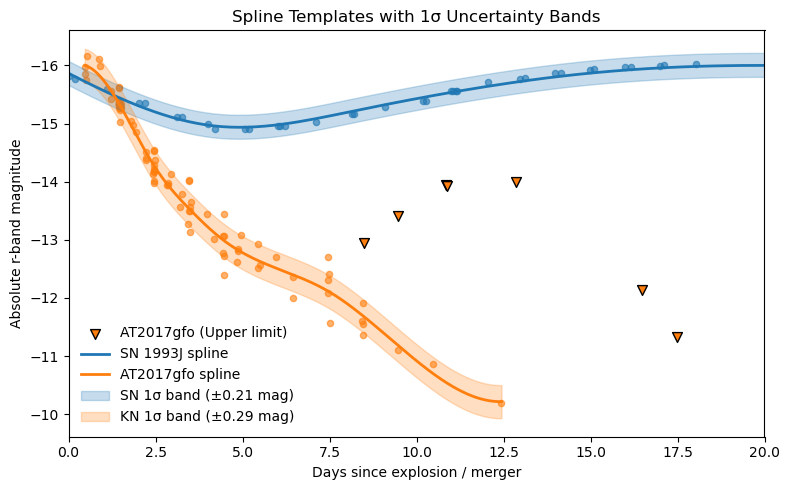

In [18]:
# Plot normalised splines with 1σ uncertainty bands
fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(phase_sn_sorted, M_sn_sorted + sn_offset, s=20, alpha=0.6, color="C0")
ax.scatter(phase_kn_sorted, M_kn_sorted + kn_offset, s=20, alpha=0.6, color="C1")
ax.scatter(phase_kn_lim, M_kn_lim + kn_offset, marker="v", s=50, edgecolor="black", color="C1", label="AT2017gfo (Upper limit)")

ax.plot(t_sn, M_sn_smooth + sn_offset, linewidth=2, color="C0", label="SN 1993J spline")
ax.plot(t_kn, M_kn_smooth + kn_offset, linewidth=2, color="C1", label="AT2017gfo spline")

ax.fill_between(t_sn,
                M_sn_smooth + sn_offset - sn_band,
                M_sn_smooth + sn_offset + sn_band,
                alpha=0.25, color="C0", label=f"SN 1σ band (±{sn_band:.2f} mag)")
ax.fill_between(t_kn,
                M_kn_smooth + kn_offset - kn_band,
                M_kn_smooth + kn_offset + kn_band,
                alpha=0.25, color="C1", label=f"KN 1σ band (±{kn_band:.2f} mag)")

ax.set_xlim(0, 20)
ax.invert_yaxis()
ax.set_xlabel("Days since explosion / merger")
ax.set_ylabel("Absolute r-band magnitude")
ax.set_title("Spline Templates with 1σ Uncertainty Bands")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

## Loading g-band Light Curve Templates

We load the g-band observations for SN 1993J and AT2017gfo from the standardised CSV files (columns: `t_days`, `mag`, `mag_err`, `band`, `upperlimit`). For AT2017gfo we keep only the 52 real detections — the 11 upper limits mark epochs where the rapidly fading kilonova fell below the g-band detection threshold.

In [ ]:
# Load g-band photometry for both objects
df_sn_g  = pd.read_csv(os.path.expanduser('~/Downloads/sn1993j_gband.csv'))
df_kn_g  = pd.read_csv(os.path.expanduser('~/Downloads/at2017gfo_gband.csv'))

# Drop upper limits from the kilonova g-band data
df_kn_g_det = df_kn_g[df_kn_g['upperlimit'] == False].copy()

print(f"SN 1993J  g-band : {len(df_sn_g)} detections, "
      f"t = {df_sn_g['t_days'].min():.1f}–{df_sn_g['t_days'].max():.1f} d, "
      f"mag = {df_sn_g['mag'].min():.2f}–{df_sn_g['mag'].max():.2f}")
print(f"AT2017gfo g-band : {len(df_kn_g_det)} detections "
      f"(+ {len(df_kn_g) - len(df_kn_g_det)} upper limits), "
      f"t = {df_kn_g_det['t_days'].min():.2f}–{df_kn_g_det['t_days'].max():.2f} d, "
      f"mag = {df_kn_g_det['mag'].min():.2f}–{df_kn_g_det['mag'].max():.2f}")

## Fitting g-band Splines

We fit `UnivariateSpline` templates to the g-band data using the same smoothing parameters as the r-band fits (`s=0.15` for SN, `s=3.9` for KN). Crucially we apply **the same normalisation offsets** (`sn_offset`, `kn_offset`) that were derived from the r-band fits. This preserves the intrinsic g−r colour, which is what we need for realistic colour evolution.

`T_KN_G_MAX` marks the last reliable AT2017gfo g-band detection (day 12.87). Evaluating the spline beyond this would be unconstrained extrapolation, so we set g-band KN magnitudes to NaN past this epoch.

In [ ]:
# Last reliable AT2017gfo g-band epoch
T_KN_G_MAX = df_kn_g_det['t_days'].max()   # ~12.87 days

# Convert to absolute magnitude using the same distances as r-band
M_sn_g_vals = df_sn_g['mag'].values - mu_93
M_kn_g_vals = df_kn_g_det['mag'].values - mu_kn

# Sort before fitting (UnivariateSpline requires sorted x)
idx_sg = np.argsort(df_sn_g['t_days'].values)
idx_kg = np.argsort(df_kn_g_det['t_days'].values)

phase_sn_g_s = df_sn_g['t_days'].values[idx_sg]
M_sn_g_s     = M_sn_g_vals[idx_sg]
phase_kn_g_s = df_kn_g_det['t_days'].values[idx_kg]
M_kn_g_s     = M_kn_g_vals[idx_kg]

# Fit splines — same smoothing as r-band
_spline_sn_g_raw = UnivariateSpline(phase_sn_g_s, M_sn_g_s, s=0.15)
_spline_kn_g_raw = UnivariateSpline(phase_kn_g_s, M_kn_g_s, s=3.9)

# Apply the same offsets as r-band to preserve intrinsic g−r colour
spline_sn_g = lambda t: _spline_sn_g_raw(t) + sn_offset
spline_kn_g = lambda t: _spline_kn_g_raw(t) + kn_offset

print(f'g-band splines fitted. KN g-band valid up to {T_KN_G_MAX:.2f} days.')

## g-band vs r-band Template Comparison

Plotting both bands on the same axes. The key feature is the colour evolution: kilonovae fade dramatically faster in g than in r (getting very red over days), while SN 1993J shows a much slower, gradual colour change. This contrast motivates g−r colour evolution as a second classifier feature.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# SN 1993J — first 30 days
t_sn_plot = np.linspace(phase_sn_g_s.min(), min(phase_sn_g_s.max(), 30), 300)
axes[0].plot(t_sn_plot, spline_sn(t_sn_plot),   label='r-band', color='C3')
axes[0].plot(t_sn_plot, spline_sn_g(t_sn_plot), label='g-band', color='C2')
axes[0].invert_yaxis()
axes[0].set_xlabel('Days since explosion')
axes[0].set_ylabel('Absolute magnitude')
axes[0].set_title('SN 1993J — g and r templates')
axes[0].legend(frameon=False)

# AT2017gfo — up to last g-band detection
t_kn_plot = np.linspace(0.5, T_KN_G_MAX, 300)
axes[1].plot(t_kn_plot, spline_kn(t_kn_plot),   label='r-band', color='C3')
axes[1].plot(t_kn_plot, spline_kn_g(t_kn_plot), label='g-band', color='C2')
axes[1].invert_yaxis()
axes[1].set_xlabel('Days since explosion')
axes[1].set_ylabel('Absolute magnitude')
axes[1].set_title('AT2017gfo — g and r templates')
axes[1].legend(frameon=False)

plt.tight_layout()
plt.show()

#### 24 Hour Survey Configuration

We simulate a 96 hour transient survey with daily cadence.

Observation epochs are defined at:
t = 0, 1,  days.

This represents the minimal time baseline required to test early light curve evolution differences between kilonovae and supernovae.

In [148]:
np.random.seed(37)


t_obs = np.array([0, 1, ])  # days

# LSST single-visit r-band limiting magnitude
m_lim = 24.5


def sample_distance(d_min=50, d_max=300):
    """Draw a distance uniformly in volume (proportional to d^2 dd)."""
    u = np.random.uniform()
    return (d_min**3 + u * (d_max**3 - d_min**3)) ** (1 / 3)


### Observed Light Curve Model

For each injected event, the following steps are applied:

1. Evaluate the absolute magnitude template spline at rest-frame time.
2. Remove pre-explosion epochs (t < 0).
3. Convert to apparent magnitude using the distance modulus:
   μ = 5 log10(d_Mpc × 10^6) − 5
4. Apply magnitude-dependent photometric uncertainty:
   σ = 0.1 mag at 20 mag,
   σ = 0.2 mag at 21 mag,
   linear interpolation between.

Gaussian noise is added to produce observed magnitudes.

In [149]:
def generate_observed_lightcurve(event_type, t0, d_mpc):
    """Simulate r-band and g-band observed light curves for one event.

    Returns m_r_obs, sigma_r, m_g_obs, sigma_g — each an array over t_obs.
    Non-detections (pre-explosion or beyond KN g-band baseline) are NaN.
    """
    t_rest = t_obs - t0
    mu = 5 * np.log10(d_mpc * 1e6) - 5

    def observe(M_abs):
        """Convert absolute mag array to noisy apparent magnitudes."""
        M_abs = np.array(M_abs, dtype=float)
        m_true = M_abs + mu
        sigma = np.where(m_true <= 20, 0.1,
                np.where(m_true >= 21, 0.2,
                0.1 + 0.1 * (m_true - 20)))
        sigma = np.where(np.isnan(m_true), 0.0, sigma)
        m_obs = m_true + np.random.normal(0, sigma)
        m_obs[np.isnan(M_abs)] = np.nan
        return m_obs, sigma

    # r-band
    M_r = np.array(spline_sn(t_rest) if event_type == 'SN' else spline_kn(t_rest), dtype=float)
    M_r[t_rest < 0] = np.nan
    m_r_obs, sigma_r = observe(M_r)

    # g-band
    M_g = np.array(spline_sn_g(t_rest) if event_type == 'SN' else spline_kn_g(t_rest), dtype=float)
    M_g[t_rest < 0] = np.nan
    if event_type == 'KN':
        M_g[t_rest > T_KN_G_MAX] = np.nan   # clamp beyond last reliable g-band epoch
    m_g_obs, sigma_g = observe(M_g)

    return m_r_obs, sigma_r, m_g_obs, sigma_g

### Injection of 1 Kilonova and 50 Supernovae

We inject:
- 1 kilonova
- 50 Type IIb supernovae

Distances are drawn uniformly between 50 and 300 Mpc.

Explosion times are drawn uniformly between −1 and 0 days,
allowing events to be partially evolved at first detection.

This configuration approximates the expected contamination level in a 1000 deg² survey over 96 hours.

In [150]:
# --- Kilonova ---
kn_distance = sample_distance()
kn_t0 = np.random.uniform(-1, 0)
kn_lc, kn_sigma, kn_lc_g, kn_sigma_g = generate_observed_lightcurve('KN', kn_t0, kn_distance)
kn_lc[kn_lc > m_lim]     = np.nan
kn_lc_g[kn_lc_g > m_lim] = np.nan

print(f'KN: d = {kn_distance:.1f} Mpc,  '
      f'r detections = {np.sum(~np.isnan(kn_lc))} / {len(t_obs)},  '
      f'g detections = {np.sum(~np.isnan(kn_lc_g))} / {len(t_obs)}')

# --- Supernovae ---
sn_lcs,   sn_sigmas   = [], []
sn_lcs_g, sn_sigmas_g = [], []

for _ in range(50):
    d  = sample_distance()
    t0 = np.random.uniform(-1, 0)
    m_r, sig_r, m_g, sig_g = generate_observed_lightcurve('SN', t0, d)
    m_r[m_r > m_lim] = np.nan
    m_g[m_g > m_lim] = np.nan
    sn_lcs.append(m_r);   sn_sigmas.append(sig_r)
    sn_lcs_g.append(m_g); sn_sigmas_g.append(sig_g)

KN: d = 294.4 Mpc,  detected epochs = 2 / 2


### 24-Hour Light Curve Comparison

Observed light curves are plotted over the four survey epochs.

Supernovae are shown in grey.
The kilonova is shown in red.

Over a 3 day baseline:
- Supernovae exhibit minimal magnitude evolution.
- Kilonovae exhibit rapid fading.

Separation between populations is therefore driven primarily by the measured light curve slope.

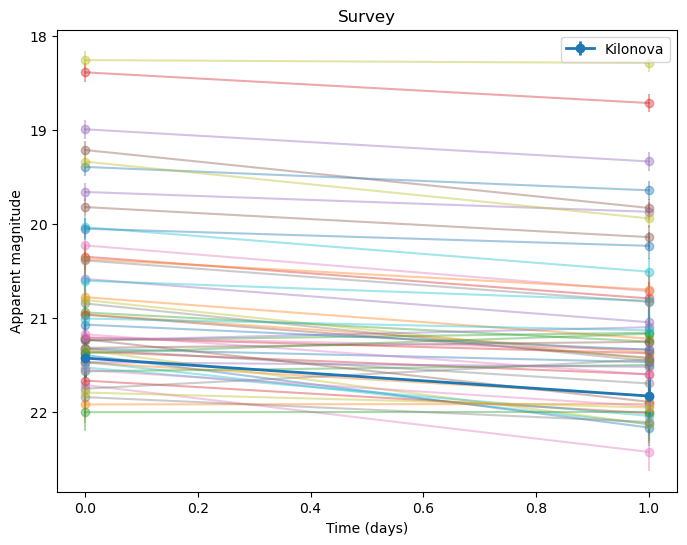

In [151]:
plt.figure(figsize=(8,6))

# Supernovae
for lc, sig in zip(sn_lcs, sn_sigmas):
    plt.errorbar(t_obs, lc, yerr=sig, fmt='o-', alpha=0.4)

# Kilonova
plt.errorbar(t_obs, kn_lc, yerr=kn_sigma, fmt='o-', linewidth=2, label="Kilonova")

plt.gca().invert_yaxis()
plt.xlabel("Time (days)")
plt.ylabel("Apparent magnitude")
plt.title("Survey")
plt.legend()
plt.show()

### Fade-Rate Classifier

To separate kilonovae from supernovae, a simple classifier based on how fast the light curve fades was used. Kilonovae fade much faster than supernovae during the first few days after peak brightness.

For each simulated light curve, the fade rate was estimated by comparing the brightness at the first detected observation and the last detected observation. Only valid detections were used. If fewer than two detections were available, the fade rate could not be calculated.

A threshold of **0.35 magnitudes per day** was used for classification.  
- If an event faded faster than this threshold, it was classified as a **kilonova candidate**.  
- If it faded more slowly, it was classified as a **supernova**.

The histogram shows the distribution of fade rates measured for the simulated supernova population. The red vertical line marks the fade rate of the injected kilonova, and the dashed black line shows the classification threshold.

KN fade rate : 0.584 mag/day  →  KN 
SN fade rates: ['0.142', '0.442', '0.311', '0.241', '0.211', '-0.065', '0.488', '0.615', '0.031', '0.664', '0.773', '0.354', '-0.066', '0.165', '0.460', '0.617', '0.713', '0.366', '0.631', '0.474', '0.183', '0.404', '-0.081', '0.347', '0.050', '0.458', '0.429', '-0.309', '0.787', '0.515', '0.249', '-0.005', '-0.002', '0.445', '-0.140', '0.666', '0.129', '0.265', '0.605', '0.214', '0.267', '0.325', '-0.206', '0.327', '0.343', '0.320', '0.385', '0.442', '0.159', '0.126']
SN false positives (misclassified as KN): 13 / 50


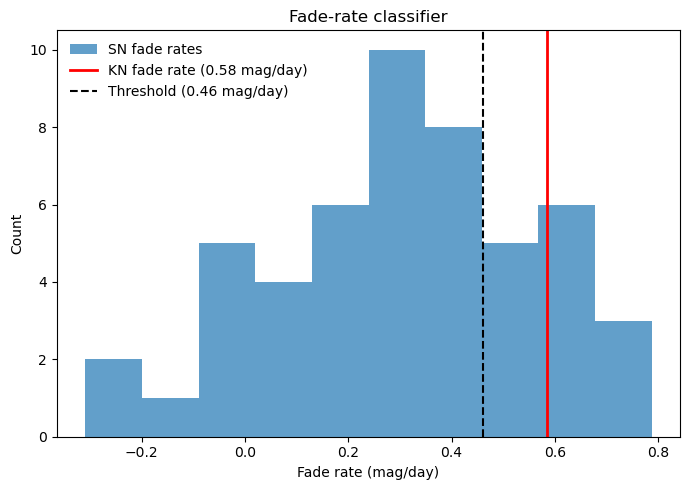

In [163]:
# --- Classifiers ---
KN_FADE_THRESHOLD = 0.46   # mag/day (r-band fade rate, Youden's J optimised)

def fade_rate(m_obs):
    """r-band fade rate (mag/day). Returns NaN if fewer than 2 detections."""
    valid = ~np.isnan(m_obs)
    if valid.sum() < 2:
        return np.nan
    t_v = t_obs[valid]
    m_v = m_obs[valid]
    return (m_v[-1] - m_v[0]) / (t_v[-1] - t_v[0])

def colour_change_rate(m_g_obs, m_r_obs):
    """Rate of change of g−r colour (mag/day).

    Positive = getting redder. Returns NaN if fewer than 2 epochs
    have both bands detected.
    """
    gr = m_g_obs - m_r_obs        # NaN wherever either band is missing
    valid = ~np.isnan(gr)
    if valid.sum() < 2:
        return np.nan
    t_v  = t_obs[valid]
    gr_v = gr[valid]
    return (gr_v[-1] - gr_v[0]) / (t_v[-1] - t_v[0])

# --- Single-injection test ---
kn_fade   = fade_rate(kn_lc)
kn_colour = colour_change_rate(kn_lc_g, kn_lc)
sn_fades   = np.array([fade_rate(lc) for lc in sn_lcs])
sn_colours = np.array([colour_change_rate(lg, lr) for lg, lr in zip(sn_lcs_g, sn_lcs)])

print(f'KN  r-band fade rate  : {kn_fade:.3f} mag/day')
print(f'KN  g-r colour change : {kn_colour:.3f} mag/day')
print(f'SN  fade rates        : mean={np.nanmean(sn_fades):.3f}, std={np.nanstd(sn_fades):.3f}')
print(f'SN  colour changes    : mean={np.nanmean(sn_colours):.3f}, std={np.nanstd(sn_colours):.3f}')

# Plot both feature distributions side by side
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(sn_fades[~np.isnan(sn_fades)], bins=10, alpha=0.7, label='SN')
if not np.isnan(kn_fade):
    axes[0].axvline(kn_fade, color='red', linewidth=2, label=f'KN ({kn_fade:.2f})')
axes[0].axvline(KN_FADE_THRESHOLD, color='black', linestyle='--', label='Threshold')
axes[0].set_xlabel('r-band fade rate (mag/day)')
axes[0].set_ylabel('Count')
axes[0].set_title('Fade-rate classifier')
axes[0].legend(frameon=False)

axes[1].hist(sn_colours[~np.isnan(sn_colours)], bins=10, alpha=0.7, label='SN', color='C0')
if not np.isnan(kn_colour):
    axes[1].axvline(kn_colour, color='red', linewidth=2, label=f'KN ({kn_colour:.2f})')
axes[1].set_xlabel('g−r colour change rate (mag/day)')
axes[1].set_ylabel('Count')
axes[1].set_title('Colour-change classifier')
axes[1].legend(frameon=False)

plt.tight_layout()
plt.show()

### Multi-Seed Survey Simulation

The survey was simulated **100 times with different random seeds**.

In each simulation:

- **1 kilonova** and **50 supernovae** were injected at random distances and explosion times.
- Light curves were generated using the survey cadence and limiting magnitude.
- Fade rates were calculated and the same **0.35 mag/day threshold** was used for classification.

In [164]:
# --- Multi-seed survey simulation (seeds 1–100) ---
results = []

for seed in range(1, 101):
    np.random.seed(seed)

    # Inject 1 KN
    kn_d  = sample_distance()
    kn_t0 = np.random.uniform(-1, 0)
    kn_r, _, kn_g, _ = generate_observed_lightcurve('KN', kn_t0, kn_d)
    kn_r[kn_r > m_lim] = np.nan
    kn_g[kn_g > m_lim] = np.nan

    # Inject 50 SNe
    sn_fades_s, sn_colours_s = [], []
    for _ in range(50):
        d  = sample_distance()
        t0 = np.random.uniform(-1, 0)
        m_r, _, m_g, _ = generate_observed_lightcurve('SN', t0, d)
        m_r[m_r > m_lim] = np.nan
        m_g[m_g > m_lim] = np.nan
        sn_fades_s.append(fade_rate(m_r))
        sn_colours_s.append(colour_change_rate(m_g, m_r))

    kn_fr = fade_rate(kn_r)
    kn_cr = colour_change_rate(kn_g, kn_r)
    sn_fr = np.array(sn_fades_s)

    results.append({
        'seed':               seed,
        'kn_distance':        kn_d,
        'kn_fade_rate':       kn_fr,
        'kn_colour_rate':     kn_cr,
        'kn_detected':        (not np.isnan(kn_fr)) and (kn_fr > KN_FADE_THRESHOLD),
        'sn_false_positives': int(np.sum(sn_fr[~np.isnan(sn_fr)] > KN_FADE_THRESHOLD)),
        'sn_valid':           int(np.sum(~np.isnan(sn_fr))),
    })

results_df = pd.DataFrame(results)
print(f"KN detection rate : {results_df['kn_detected'].mean()*100:.1f}%  "
      f"({results_df['kn_detected'].sum()} / 100 seeds)")
print(f"Mean SN false positives: {results_df['sn_false_positives'].mean():.2f} per realisation")

KN detection rate:       69.0%  (69 / 100 seeds)
Mean SN false positives: 11.67 per realisation


In [165]:
# --- Bootstrap confidence intervals on detection rate (100 resamples) ---
n_seeds = len(results_df)
kn_detected_arr = results_df["kn_detected"].values
sn_fp_arr = results_df["sn_false_positives"].values

rng = np.random.default_rng(42)
boot_kn_rate = []
boot_sn_fp   = []
for _ in range(100):
    idx = rng.integers(0, n_seeds, size=n_seeds)
    boot_kn_rate.append(kn_detected_arr[idx].mean())
    boot_sn_fp.append(sn_fp_arr[idx].mean())

boot_kn_rate = np.array(boot_kn_rate)
boot_sn_fp   = np.array(boot_sn_fp)

kn_lo, kn_hi = np.percentile(boot_kn_rate, [2.5, 97.5])
fp_lo, fp_hi = np.percentile(boot_sn_fp,   [2.5, 97.5])

print(f"KN detection rate: {results_df['kn_detected'].mean()*100:.1f}%  "
      f"95% CI: [{kn_lo*100:.1f}%, {kn_hi*100:.1f}%]")
print(f"Mean SN false positives: {results_df['sn_false_positives'].mean():.2f}  "
      f"95% CI: [{fp_lo:.2f}, {fp_hi:.2f}]")

KN detection rate: 69.0%  95% CI: [60.0%, 77.5%]
Mean SN false positives: 11.67  95% CI: [11.19, 12.25]


### Classifier Performance Across 100 Simulations

The performance of the fade-rate classifier was examined using 100 independent survey simulations.

The left panel shows the distribution of measured kilonova fade rates. The dashed line marks the classification threshold of **0.35 mag/day**. 

The middle panel shows the number of supernovae that are incorrectly classified as kilonovae in each simulation. On average, several fast-fading supernovae contaminate the kilonova sample.

The right panel shows kilonova fade rate as a function of distance. Orange points indicate correctly detected kilonovae, while grey points show missed events. Missed detections occur when the measured fade rate falls below the classification threshold.

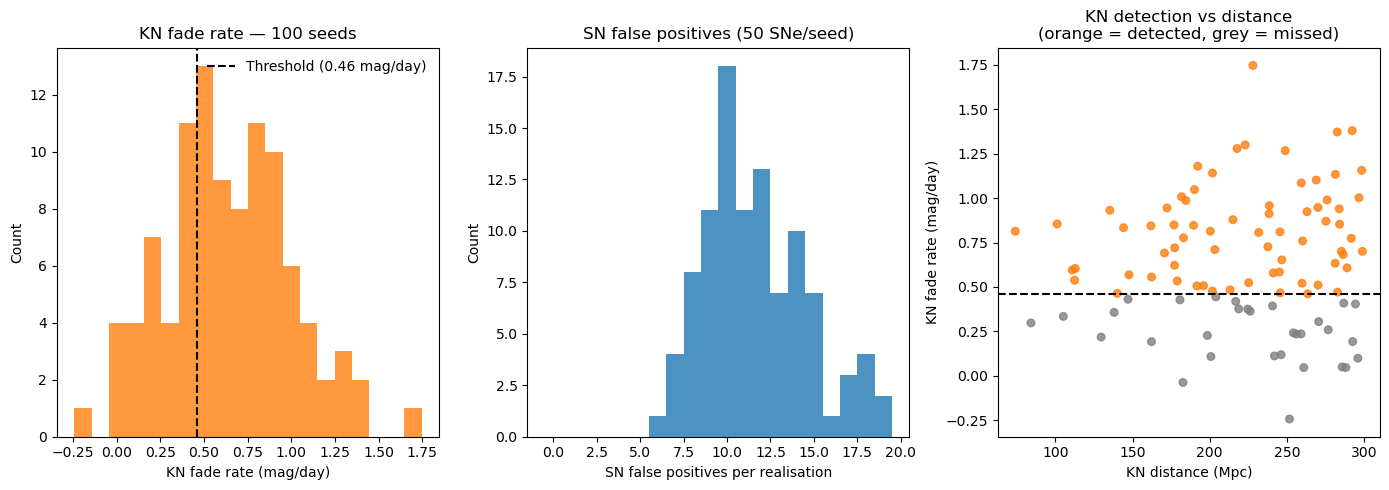

In [166]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
# Panel 1 — KN fade-rate distribution
axes[0].hist(results_df["kn_fade_rate"].dropna(), bins=20, color="C1", alpha=0.8)
axes[0].axvline(KN_FADE_THRESHOLD, color="black", linestyle="--",
                label=f"Threshold ({KN_FADE_THRESHOLD} mag/day)")
axes[0].set_xlabel("KN fade rate (mag/day)")
axes[0].set_ylabel("Count")
axes[0].set_title("KN fade rate — 100 seeds")
axes[0].legend(frameon=False)

# Panel 2 — SN false-positive count per realisation
fp_max = max(results_df["sn_false_positives"].max(), 1)
axes[1].hist(results_df["sn_false_positives"], bins=range(0, fp_max + 2),
             color="C0", alpha=0.8, align="left")
axes[1].set_xlabel("SN false positives per realisation")
axes[1].set_ylabel("Count")
axes[1].set_title("SN false positives (50 SNe/seed)")

# Panel 3 — KN detection vs distance
colors = results_df["kn_detected"].map({True: "C1", False: "grey"})
axes[2].scatter(results_df["kn_distance"], results_df["kn_fade_rate"],
                c=colors, s=30, alpha=0.8)
axes[2].axhline(KN_FADE_THRESHOLD, color="black", linestyle="--")
axes[2].set_xlabel("KN distance (Mpc)")
axes[2].set_ylabel("KN fade rate (mag/day)")
axes[2].set_title("KN detection vs distance\n(orange = detected, grey = missed)")

plt.tight_layout()
plt.show()

In [167]:
# --- Collect per-event scores for both features across all 100 seeds ---
all_fade   = []   # r-band fade rate per event
all_colour = []   # g−r colour change rate per event
all_labels = []   # 1 = KN, 0 = SN

for seed in range(1, 101):
    np.random.seed(seed)

    # KN
    kn_d  = sample_distance()
    kn_t0 = np.random.uniform(-1, 0)
    kn_r, _, kn_g, _ = generate_observed_lightcurve('KN', kn_t0, kn_d)
    kn_r[kn_r > m_lim] = np.nan
    kn_g[kn_g > m_lim] = np.nan
    fr = fade_rate(kn_r)
    cr = colour_change_rate(kn_g, kn_r)
    if not np.isnan(fr):
        all_fade.append(fr); all_colour.append(cr); all_labels.append(1)

    # 50 SNe
    for _ in range(50):
        d  = sample_distance()
        t0 = np.random.uniform(-1, 0)
        m_r, _, m_g, _ = generate_observed_lightcurve('SN', t0, d)
        m_r[m_r > m_lim] = np.nan
        m_g[m_g > m_lim] = np.nan
        fr = fade_rate(m_r)
        cr = colour_change_rate(m_g, m_r)
        if not np.isnan(fr):
            all_fade.append(fr); all_colour.append(cr); all_labels.append(0)

# Keep all_scores = fade rates for backward compatibility with cells below
all_scores = np.array(all_fade)
all_colour = np.array(all_colour)
all_labels = np.array(all_labels)

n_kn = (all_labels == 1).sum()
n_sn = (all_labels == 0).sum()
print(f'Events collected: {n_kn} KN, {n_sn} SN')

### ROC Curve Calculation

The classifier threshold is scanned across the full range of measured fade rates. For each threshold, events with a fade rate above the threshold are classified as kilonova candidates.

At every threshold the fraction of real kilonovae correctly identified and the fraction of supernovae incorrectly classified as kilonovae are calculated.

These values are used to construct the Receiver Operating Characteristic (ROC) curve. The ROC curve shows how the detection efficiency changes as the classification threshold is varied.

The area under the ROC curve (AUC) is then computed to summarise the overall performance of the classifier. A value close to one indicates strong separation between kilonovae and supernovae.

Finally, the operating point corresponding to the adopted threshold of **given mag/day** is identified on the ROC curve.

In [168]:
# Sweep thresholds from min to max fade rate
thresholds = np.linspace(all_scores.min() - 0.01, all_scores.max() + 0.01, 500)

tpr_vals, fpr_vals, prec_vals = [], [], []
for t in thresholds:
    pred_pos = all_scores >= t
    tp = ((pred_pos) & (all_labels == 1)).sum()
    fp = ((pred_pos) & (all_labels == 0)).sum()
    tpr_vals.append(tp / n_kn if n_kn > 0 else 0)
    fpr_vals.append(fp / n_sn if n_sn > 0 else 0)
    prec_vals.append(tp / (tp + fp) if (tp + fp) > 0 else 1.0)

tpr_vals  = np.array(tpr_vals)
fpr_vals  = np.array(fpr_vals)
prec_vals = np.array(prec_vals)

# AUC via trapezoidal rule (sort by FPR for proper integration)
sort_idx = np.argsort(fpr_vals)
auc = np.trapezoid(tpr_vals[sort_idx], fpr_vals[sort_idx])

# Mark operating point at KN_FADE_THRESHOLD
op_idx = np.argmin(np.abs(thresholds - KN_FADE_THRESHOLD))
op_fpr  = fpr_vals[op_idx]
op_tpr  = tpr_vals[op_idx]
op_prec = prec_vals[op_idx]
op_rec  = tpr_vals[op_idx]   # recall = TPR

In [169]:
# --- Bootstrap confidence interval on AUC (100 resamples) ---
kn_scores = all_scores[all_labels == 1]
sn_scores = all_scores[all_labels == 0]

boot_aucs = []
rng2 = np.random.default_rng(42)
for _ in range(100):
    kn_boot = rng2.choice(kn_scores, size=len(kn_scores), replace=True)
    sn_boot = rng2.choice(sn_scores, size=len(sn_scores), replace=True)
    boot_all_scores = np.concatenate([kn_boot, sn_boot])
    boot_all_labels = np.concatenate([np.ones(len(kn_boot)), np.zeros(len(sn_boot))])

    boot_tpr, boot_fpr = [], []
    for t in thresholds:
        pred = boot_all_scores >= t
        tp = ((pred) & (boot_all_labels == 1)).sum()
        fp = ((pred) & (boot_all_labels == 0)).sum()
        boot_tpr.append(tp / len(kn_boot) if len(kn_boot) > 0 else 0)
        boot_fpr.append(fp / len(sn_boot) if len(sn_boot) > 0 else 0)

    s = np.argsort(boot_fpr)
    boot_aucs.append(np.trapezoid(np.array(boot_tpr)[s], np.array(boot_fpr)[s]))

auc_lo, auc_hi = np.percentile(boot_aucs, [2.5, 97.5])
print(f"AUC = {auc:.3f}  95% CI: [{auc_lo:.3f}, {auc_hi:.3f}]")

AUC = 0.789  95% CI: [0.738, 0.838]


(0.0, 1.0)

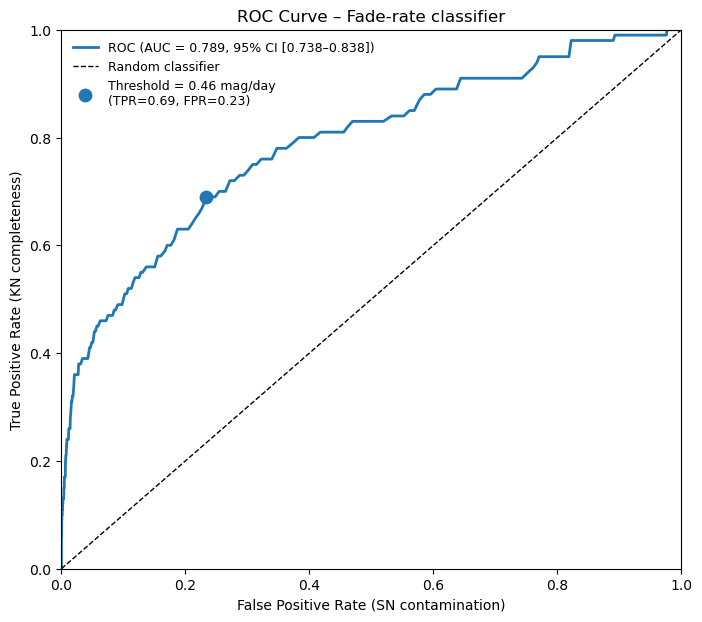

In [170]:
fig, ax = plt.subplots(figsize=(8,7))

ax.plot(fpr_vals, tpr_vals, linewidth=2, label=f"ROC (AUC = {auc:.3f}, 95% CI [{auc_lo:.3f}–{auc_hi:.3f}])")
ax.plot([0,1], [0,1], "k--", linewidth=1, label="Random classifier")

ax.scatter([op_fpr], [op_tpr], s=80, zorder=5,
           label=f"Threshold = {KN_FADE_THRESHOLD} mag/day\n"
                 f"(TPR={op_tpr:.2f}, FPR={op_fpr:.2f})")

ax.set_xlabel("False Positive Rate (SN contamination)")
ax.set_ylabel("True Positive Rate (KN completeness)")
ax.set_title("ROC Curve – Fade-rate classifier")
ax.legend(frameon=False, fontsize=9)
ax.set_xlim(0,1)
ax.set_ylim(0,1)

### Optimal Classifier Threshold

The fade-rate threshold of given mag/day was chosen heuristically. We can now derive it formally from the ROC data using two standard optimality criteria:

- **Youden's J statistic**: J = TPR − FPR. Maximised when the classifier best separates the two populations regardless of class imbalance.


In [171]:
# --- Optimal threshold derivation from existing ROC data ---
youden_j = tpr_vals - fpr_vals

thresh_youden = thresholds[np.argmax(youden_j)]

print(f"Youden-J optimal threshold : {thresh_youden:.3f} mag/day  (J = {youden_j.max():.3f})")








Youden-J optimal threshold : 0.460 mag/day  (J = 0.456)


## Multi-Feature ROC: Colour Change Rate vs Fade Rate vs Combined

We compare three classifiers:
1. **r-band fade rate alone** — the existing classifier
2. **g−r colour change rate alone** — kilonovae get redder fast, SNe do not
3. **Combined score** — equal-weight average of both features (each normalised to [0,1])

The AUC comparison shows how much the g-band adds on top of r-band alone.

In [ ]:
def compute_roc(scores, labels):
    """Sweep thresholds and return (fpr, tpr, thresholds, auc)."""
    n_pos = (labels == 1).sum()
    n_neg = (labels == 0).sum()
    threshs = np.linspace(scores.min() - 0.01, scores.max() + 0.01, 500)
    tpr_arr, fpr_arr = [], []
    for t in threshs:
        pred = scores >= t
        tp = ((pred) & (labels == 1)).sum()
        fp = ((pred) & (labels == 0)).sum()
        tpr_arr.append(tp / n_pos if n_pos > 0 else 0)
        fpr_arr.append(fp / n_neg if n_neg > 0 else 0)
    tpr_arr = np.array(tpr_arr)
    fpr_arr = np.array(fpr_arr)
    s = np.argsort(fpr_arr)
    auc_val = np.trapezoid(tpr_arr[s], fpr_arr[s])
    return fpr_arr, tpr_arr, threshs, auc_val

def norm01(x):
    """Normalise array to [0, 1] range."""
    return (x - x.min()) / (x.max() - x.min() + 1e-12)

# Keep only events where both features are available
valid_mask = ~np.isnan(all_colour)
s_fade   = all_scores[valid_mask]
s_colour = all_colour[valid_mask]
s_labels = all_labels[valid_mask]

# Combined score: equal-weight average of normalised features
s_combined = 0.5 * norm01(s_fade) + 0.5 * norm01(s_colour)

fpr_f, tpr_f, _, auc_f = compute_roc(s_fade,     s_labels)
fpr_c, tpr_c, _, auc_c = compute_roc(s_colour,   s_labels)
fpr_k, tpr_k, _, auc_k = compute_roc(s_combined, s_labels)

print(f'AUC — r-band fade rate alone : {auc_f:.3f}')
print(f'AUC — g−r colour rate alone  : {auc_c:.3f}')
print(f'AUC — combined (equal weight): {auc_k:.3f}')

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr_f, tpr_f, label=f'r-band fade rate  (AUC={auc_f:.3f})')
ax.plot(fpr_c, tpr_c, label=f'g−r colour rate   (AUC={auc_c:.3f})')
ax.plot(fpr_k, tpr_k, linewidth=2, label=f'Combined          (AUC={auc_k:.3f})')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random')
ax.set_xlabel('False Positive Rate (SN contamination)')
ax.set_ylabel('True Positive Rate (KN completeness)')
ax.set_title('ROC — three classifiers')
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

## Survey Sensitivity Function

`run_survey` wraps the full injection–classification pipeline for any cadence array and limiting magnitude. It uses the combined (fade rate + colour change rate) classifier and returns KN detection rate, mean SN false positives, and AUC. This is called by the parameter grid in the next cell.

In [ ]:
def run_survey(t_obs_arr, m_lim_val, n_seeds=100):
    """Run the injection survey for a given cadence and limiting magnitude.

    Uses the combined classifier (fade rate + colour change rate).
    Returns dict: kn_det_rate, sn_fp_mean, auc.
    """
    global t_obs, m_lim
    t_obs_saved, m_lim_saved = t_obs, m_lim
    t_obs = t_obs_arr
    m_lim = m_lim_val

    sf, sc, sl = [], [], []
    kn_det  = 0
    sn_fp   = 0

    for seed in range(1, n_seeds + 1):
        np.random.seed(seed)

        kn_d  = sample_distance()
        kn_t0 = np.random.uniform(-1, 0)
        kn_r, _, kn_g, _ = generate_observed_lightcurve('KN', kn_t0, kn_d)
        kn_r[kn_r > m_lim] = np.nan
        kn_g[kn_g > m_lim] = np.nan
        fr = fade_rate(kn_r)
        cr = colour_change_rate(kn_g, kn_r)
        if not np.isnan(fr):
            sf.append(fr); sc.append(cr); sl.append(1)
            kn_det += int(fr > KN_FADE_THRESHOLD)

        for _ in range(50):
            d  = sample_distance()
            t0 = np.random.uniform(-1, 0)
            m_r, _, m_g, _ = generate_observed_lightcurve('SN', t0, d)
            m_r[m_r > m_lim] = np.nan
            m_g[m_g > m_lim] = np.nan
            fr = fade_rate(m_r)
            cr = colour_change_rate(m_g, m_r)
            if not np.isnan(fr):
                sf.append(fr); sc.append(cr); sl.append(0)
                sn_fp += int(fr > KN_FADE_THRESHOLD)

    t_obs, m_lim = t_obs_saved, m_lim_saved

    sf = np.array(sf)
    sc = np.array(sc)
    sl = np.array(sl)

    # Use combined classifier for AUC
    vm = ~np.isnan(sc)
    if vm.sum() > 10:
        combined = 0.5 * norm01(sf[vm]) + 0.5 * norm01(sc[vm])
        _, _, _, auc_val = compute_roc(combined, sl[vm])
    else:
        _, _, _, auc_val = compute_roc(sf, sl)

    return {'kn_det_rate': kn_det / n_seeds,
            'sn_fp_mean':  sn_fp / n_seeds,
            'auc':         auc_val}

In [172]:
#  Parameter grid 
m_lim_grid = np.arange(22.0, 24.5, 0.5)   

cadence_grid = {
    "2-epoch [0,1d]":     np.array([0, 1]),
    "3-epoch [0,1,2d]":   np.array([0, 1, 2]),
    "4-epoch [0,1,2,3d]": np.array([0, 1, 2, 3]),}

#  Run grid 
sens_rows = []

for cadence_label, t_obs_arr in cadence_grid.items():
    for ml in m_lim_grid:
        res = run_survey(t_obs_arr, ml, n_seeds=100)
        sens_rows.append({
            "cadence":     cadence_label,
            "m_lim":       ml,
            "kn_det_rate": res["kn_det_rate"],
            "sn_fp_mean":  res["sn_fp_mean"],
            "auc":         res["auc"],
        })
        print(f"  {cadence_label:24s}  m_lim={ml:.1f}  "
              f"det={res['kn_det_rate']*100:.0f}%  "
              f"FP={res['sn_fp_mean']:.1f}  "
              f"AUC={res['auc']:.3f}")

sens_df = pd.DataFrame(sens_rows)
print(f"\nGrid complete: {len(sens_df)} combinations")

  2-epoch [0,1d]            m_lim=22.0  det=51%  FP=9.4  AUC=0.766
  2-epoch [0,1d]            m_lim=22.5  det=64%  FP=11.7  AUC=0.779
  2-epoch [0,1d]            m_lim=23.0  det=69%  FP=11.7  AUC=0.789
  2-epoch [0,1d]            m_lim=23.5  det=69%  FP=11.7  AUC=0.789
  2-epoch [0,1d]            m_lim=24.0  det=69%  FP=11.7  AUC=0.789
  3-epoch [0,1,2d]          m_lim=22.0  det=62%  FP=3.3  AUC=0.869
  3-epoch [0,1,2d]          m_lim=22.5  det=83%  FP=3.5  AUC=0.915
  3-epoch [0,1,2d]          m_lim=23.0  det=97%  FP=3.6  AUC=0.983
  3-epoch [0,1,2d]          m_lim=23.5  det=99%  FP=3.6  AUC=0.995
  3-epoch [0,1,2d]          m_lim=24.0  det=99%  FP=3.6  AUC=0.995
  4-epoch [0,1,2,3d]        m_lim=22.0  det=62%  FP=1.3  AUC=0.888
  4-epoch [0,1,2,3d]        m_lim=22.5  det=83%  FP=0.4  AUC=0.927
  4-epoch [0,1,2,3d]        m_lim=23.0  det=97%  FP=0.4  AUC=0.990
  4-epoch [0,1,2,3d]        m_lim=23.5  det=100%  FP=0.4  AUC=1.000
  4-epoch [0,1,2,3d]        m_lim=24.0  det=100%  FP=0.4 